# Разведочный анализ данных (EDA)

**Датасет:** деловая корреспонденция нефтедобывающей компании, деперсонализированная с помощью плейсхолдеров.

**Задачи EDA:**
1. Анализ состава и структуры датасета
2. Исследование распределения классов и дисбаланса
3. Анализ длин текстов и выявление аномалий
4. Анализ плейсхолдеров (деперсонализированных токенов)
5. Анализ лексических характеристик (TTR, hapax ratio)
6. Семантическая визуализация через UMAP

## 1. Импорт библиотек

In [1]:
%%capture
!pip install pandas numpy matplotlib scipy sentence-transformers umap-learn

In [2]:
import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Единая цветовая палитра для всего ноутбука
PALETTE_MAIN   = '#2E86AB'  # синий
PALETTE_ACCENT = '#A23B72'  # пурпурный
PALETTE_GREEN  = '#3BB273'  # зелёный
PALETTE_ORANGE = '#E84855'  # красный-акцент

plt.rcParams.update({
    'figure.figsize':  (14, 6),
    'font.size':       11,
    'axes.grid':       True,
    'grid.alpha':      0.3,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

## 2. Загрузка данных

In [3]:
DATA_PATH = Path('/content/original_data.json')

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)[['label', 'text']]

print(f'Документов: {len(df)}')
print(f'Классов: {df["label"].nunique()}')
print(f'Пропущенных значений: {df.isnull().sum().sum()}')
df.head(3)

Документов: 1774
Классов: 36
Пропущенных значений: 0


,label,text
0,Блок директора по проектированию,[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATI...
1,Блок деректора по газу,[ORGANIZATION] инжиниринг общество с ограничен...
2,Блок заместителя генерального директора по без...,[ORGANIZATION] ИНВЕСТ Общество с ограниченной ...


## 3. Проверка дубликатов

In [4]:
n_full_dupl = df.duplicated().sum()
n_text_dupl = df.duplicated(subset='text').sum()

print(f'Полных дубликатов (text + label): {n_full_dupl}')
print(f'Дубликатов по тексту (разные классы): {n_text_dupl}')

if n_text_dupl > 0:
    print('\nСтроки с дублирующимся текстом:')
    display(df[df.duplicated(subset='text', keep=False)][['label', 'text']].head(10))

Полных дубликатов (text + label): 4
Дубликатов по тексту (разные классы): 5

Строки с дублирующимся текстом:


,label,text
103,Имущественные вопросы,[ORGANIZATION] ПРИКАЗ [DATE_TIME] No [DOCUMENT...
157,Блок исполнительного директора по реализации п...,[ORGANIZATION] ВРИО генерального директора [OR...
158,Блок исполнительного директора по реализации п...,[ORGANIZATION] ВРИО генерального директора [OR...
176,Блок финансового директора,[ORGANIZATION] ПРИКАЗ [DATE_TIME] No [DOCUMENT...
316,Блок директора по проектированию,МИНИСТЕРСТВО ПРИРОДНЫХ РЕСУРСОВ И ЭКОЛОГИИ РОС...
317,Блок директора по проектированию,МИНИСТЕРСТВО ПРИРОДНЫХ РЕСУРСОВ И ЭКОЛОГИИ РОС...
783,Блок директора по строительству,[ORGANIZATION] ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...
784,Блок директора по строительству,[ORGANIZATION] ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...
827,Блок директора по строительству,[ORGANIZATION] Юридический адрес: [LOCATION] П...
828,Блок директора по строительству,[ORGANIZATION] Юридический адрес: [LOCATION] П...


## 4. Распределение классов

In [5]:
label_counts = df['label'].value_counts()

print(f'Классов: {len(label_counts)}')
print(f'Документов: {len(df)}')
print(f'Среднее на класс: {label_counts.mean():.1f}')
print(f'Медиана на класс: {label_counts.median():.0f}')
print(f'Мин: {label_counts.min()} ({label_counts.idxmin()})')
print(f'Макс: {label_counts.max()} ({label_counts.idxmax()})')

Классов: 36
Документов: 1774
Среднее на класс: 49.3
Медиана на класс: 25
Мин: 2 (Имущественные вопросы)
Макс: 249 (Блок технического директора)


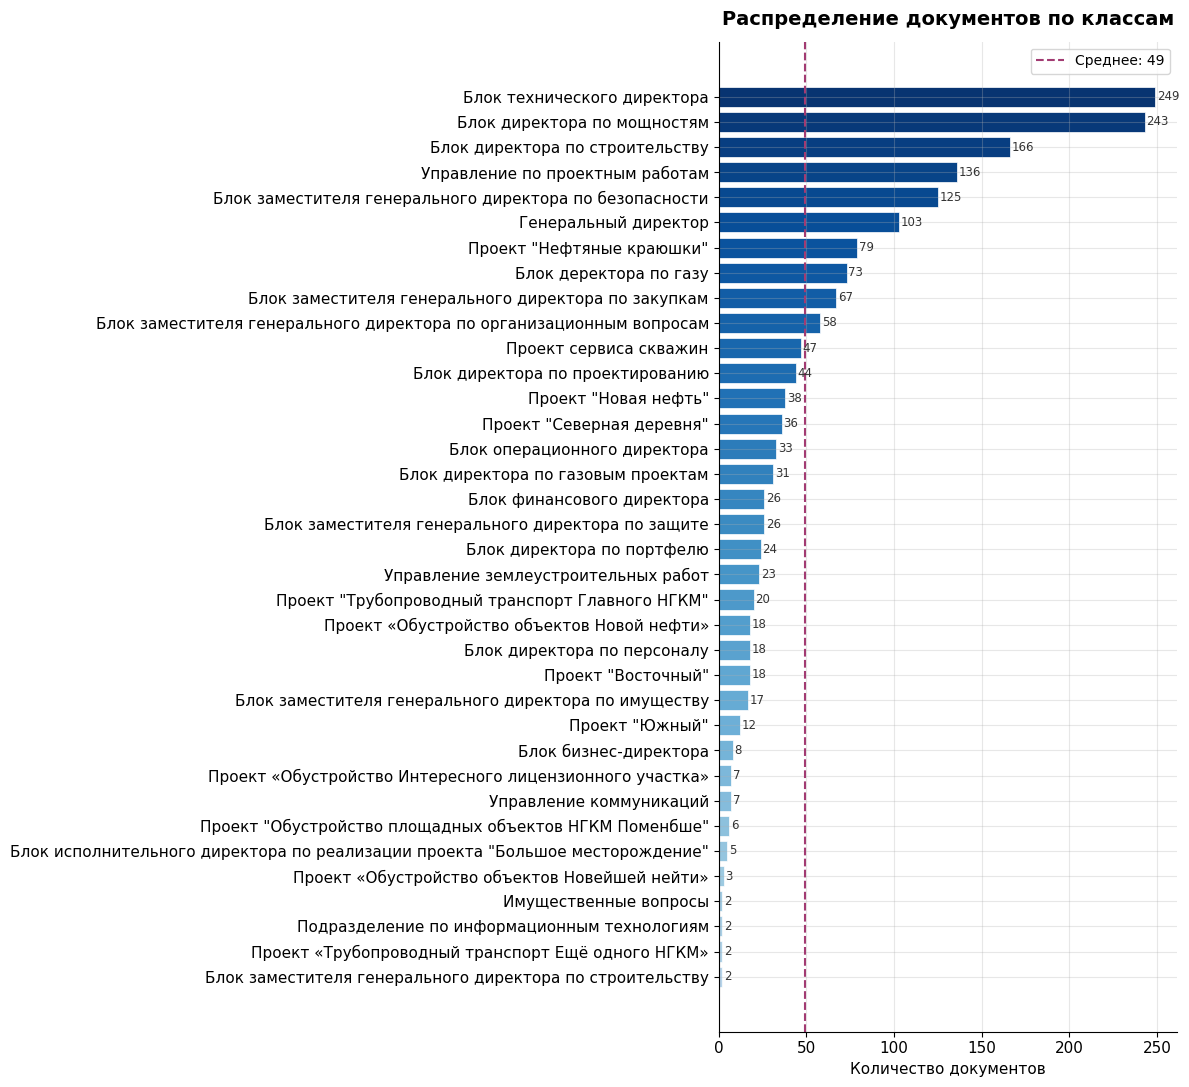

In [6]:
# Горизонтальная барчарт с градиентом цвета
sorted_counts = label_counts.sort_values()

n = len(sorted_counts)
cmap = plt.cm.get_cmap('Blues')
colors = [cmap(0.3 + 0.7 * i / n) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 11))
bars = ax.barh(sorted_counts.index, sorted_counts.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, sorted_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8.5, color='#333333')

ax.axvline(label_counts.mean(), color=PALETTE_ACCENT, linestyle='--', linewidth=1.5,
           label=f'Среднее: {label_counts.mean():.0f}')
ax.set_title('Распределение документов по классам', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Количество документов')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Анализ дисбаланса классов

In [7]:
imbalance_ratio = label_counts.max() / label_counts.min()
small_10  = (label_counts < 10).sum()
small_20  = (label_counts < 20).sum()

print(f'Коэффициент дисбаланса (max/min): {imbalance_ratio:.1f}x')
print(f'Классов с < 10 документами: {small_10}')
print(f'Классов с < 20 документами: {small_20}')

Коэффициент дисбаланса (max/min): 124.5x
Классов с < 10 документами: 10
Классов с < 20 документами: 15


## 6. Анализ длин текстов

In [8]:
df['text_len_chars'] = df['text'].str.len()
df['text_len_words'] = df['text'].str.split().str.len()

print('=== Длина в символах ===')
print(df['text_len_chars'].describe().round(0).astype(int))
print('\n=== Длина в словах ===')
print(df['text_len_words'].describe().round(0).astype(int))

=== Длина в символах ===
count     1774
mean      2924
std       7091
min         49
25%        923
50%       1278
75%       1922
max      69225
Name: text_len_chars, dtype: int64

=== Длина в словах ===
count    1774
mean      316
std       701
min         8
25%       106
50%       149
75%       230
max      7455
Name: text_len_words, dtype: int64


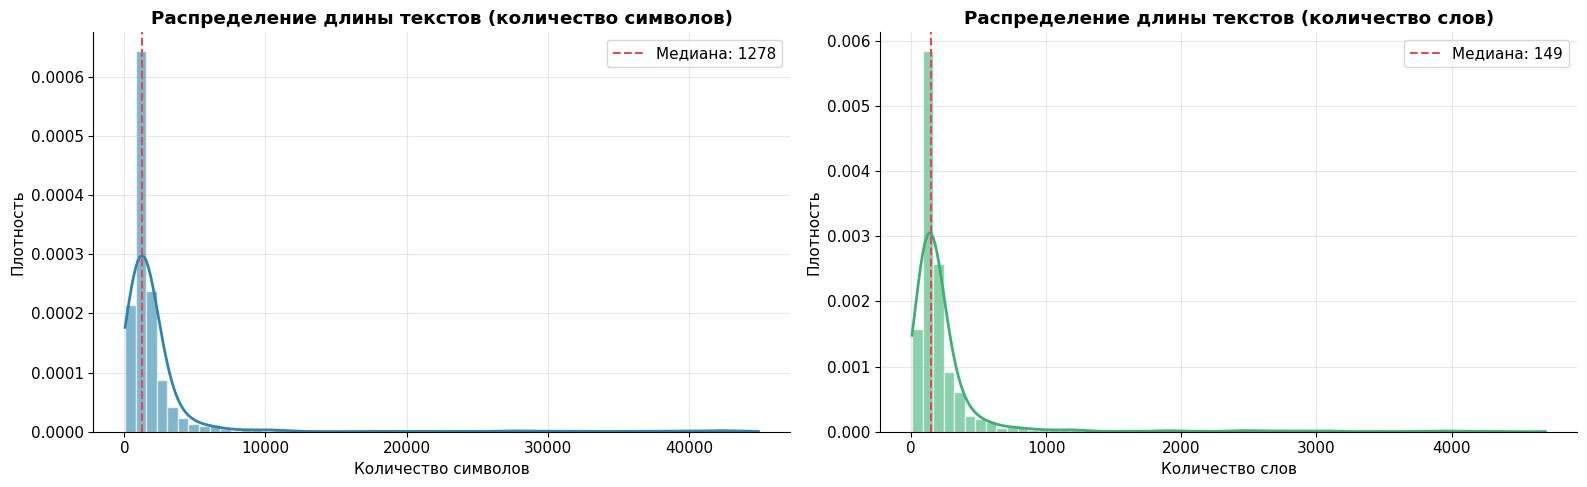

In [9]:
# Гистограммы с KDE-кривой
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, xlabel, color in zip(
    axes,
    ['text_len_chars', 'text_len_words'],
    ['Количество символов', 'Количество слов'],
    [PALETTE_MAIN, PALETTE_GREEN]
):
    q99 = df[col].quantile(0.99)
    data = df[df[col] <= q99][col]

    ax.hist(data, bins=60, color=color, alpha=0.6, edgecolor='white', density=True)

    # KDE кривая
    kde = gaussian_kde(data, bw_method=0.2)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2)

    med = df[col].median()
    ax.axvline(med, color=PALETTE_ORANGE, linestyle='--', linewidth=1.5,
               label=f'Медиана: {med:.0f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Плотность')
    ax.set_title(f'Распределение длины текстов ({xlabel.lower()})',
                 fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/eda_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Анализ плейсхолдеров (деперсонализированных токенов)

In [10]:
mask_pattern = re.compile(r'\[([A-ZА-ЯЁ_]+)\]')

all_masks = []
for text in df['text']:
    all_masks.extend(mask_pattern.findall(text))

mask_counts = Counter(all_masks)
docs_with_mask = df['text'].str.contains(r'\[[A-ZА-ЯЁ_]+\]', regex=True).sum()

print(f'Уникальных плейсхолдеров: {len(mask_counts)}')
print(f'Всего вхождений: {sum(mask_counts.values())}')
print(f'Документов с плейсхолдерами: {docs_with_mask} из {len(df)} ({100*docs_with_mask/len(df):.1f}%)')

Уникальных плейсхолдеров: 325
Всего вхождений: 204673
Документов с плейсхолдерами: 1774 из 1774 (100.0%)


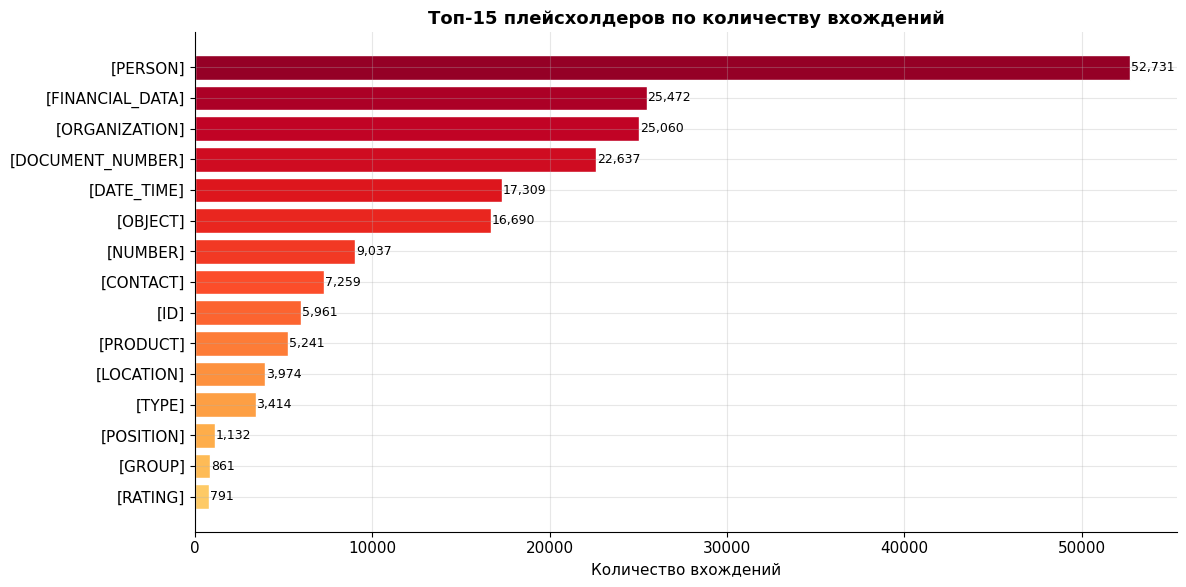

In [11]:
top_masks = pd.Series(dict(mask_counts.most_common(15))).sort_values()

n = len(top_masks)
cmap = plt.cm.get_cmap('YlOrRd')
colors = [cmap(0.3 + 0.7 * i / n) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh([f'[{m}]' for m in top_masks.index], top_masks.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, top_masks.values):
    ax.text(val + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Топ-15 плейсхолдеров по количеству вхождений', fontsize=13, fontweight='bold')
ax.set_xlabel('Количество вхождений')

plt.tight_layout()
plt.savefig('/content/eda_placeholders.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Лексические характеристики (TTR и hapax ratio)

In [12]:
def lexical_metrics(text: str) -> dict:
    words = re.findall(r'[а-яёА-ЯЁa-zA-Z]{2,}', text.lower())
    # убираем плейсхолдеры из расчёта
    words = [w for w in words if not re.match(r'^[a-z_]+$', w) or len(w) > 4]
    if not words:
        return {'ttr': 0, 'hapax_ratio': 0}
    unique = len(set(words))
    freq = Counter(words)
    hapax = sum(1 for c in freq.values() if c == 1)
    return {
        'ttr':         unique / len(words),
        'hapax_ratio': hapax / unique if unique else 0,
    }

lex_df = df['text'].apply(lambda t: pd.Series(lexical_metrics(t)))
df = pd.concat([df, lex_df], axis=1)

print('TTR — лексическое разнообразие (Type-Token Ratio):')
print(df['ttr'].describe().round(3))
print('\nHapax ratio — доля уникальных слов:')
print(df['hapax_ratio'].describe().round(3))

TTR — лексическое разнообразие (Type-Token Ratio):
count    1774.000
mean        0.636
std         0.152
min         0.001
25%         0.594
50%         0.667
75%         0.722
max         1.000
Name: ttr, dtype: float64

Hapax ratio — доля уникальных слов:
count    1774.000
mean        0.760
std         0.086
min         0.000
25%         0.720
50%         0.774
75%         0.815
max         1.000
Name: hapax_ratio, dtype: float64


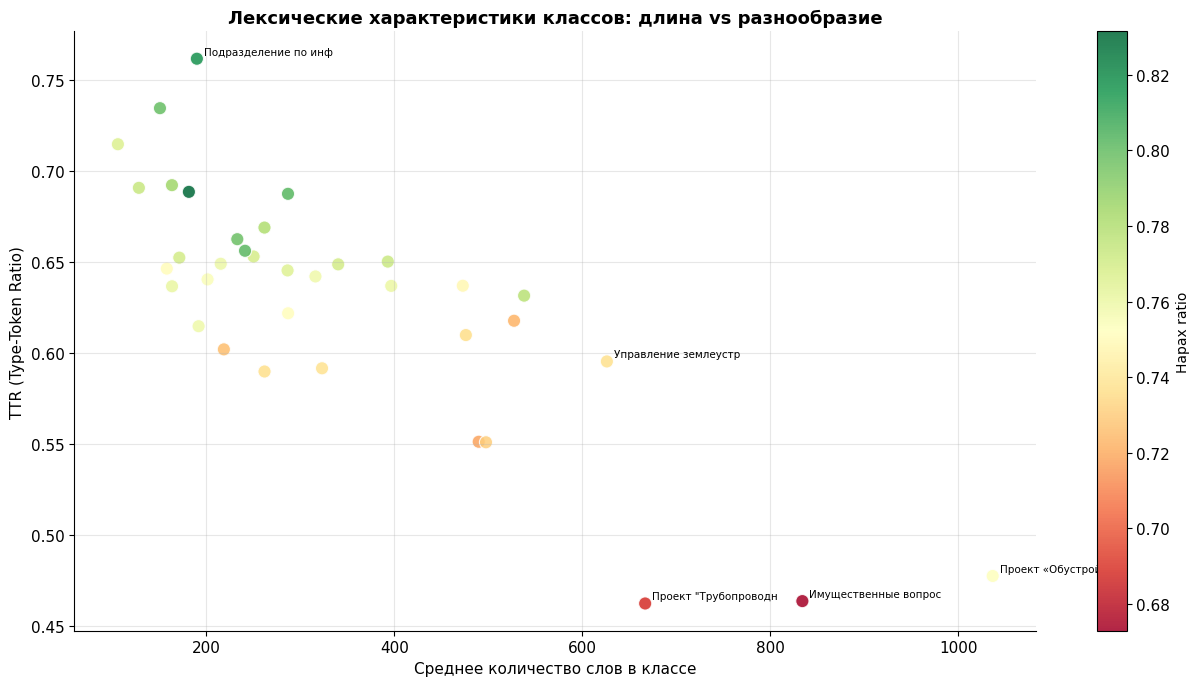

In [13]:
# Scatter plot: word_count vs TTR, цвет = hapax_ratio
class_avg = df.groupby('label').agg(
    word_count=('text_len_words', 'mean'),
    ttr=('ttr', 'mean'),
    hapax_ratio=('hapax_ratio', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(13, 7))
sc = ax.scatter(
    class_avg['word_count'], class_avg['ttr'],
    c=class_avg['hapax_ratio'], cmap='RdYlGn',
    s=90, alpha=0.85, edgecolors='white', linewidths=0.8
)

# Подписи для крайних точек
for _, row in class_avg.iterrows():
    if row['ttr'] < 0.35 or row['ttr'] > 0.75 or row['word_count'] > 600:
        ax.annotate(
            row['label'][:20],
            (row['word_count'], row['ttr']),
            fontsize=7.5, ha='left',
            xytext=(5, 3), textcoords='offset points'
        )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Hapax ratio', fontsize=10)

ax.set_xlabel('Среднее количество слов в классе', fontsize=11)
ax.set_ylabel('TTR (Type-Token Ratio)', fontsize=11)
ax.set_title('Лексические характеристики классов: длина vs разнообразие',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/eda_ttr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

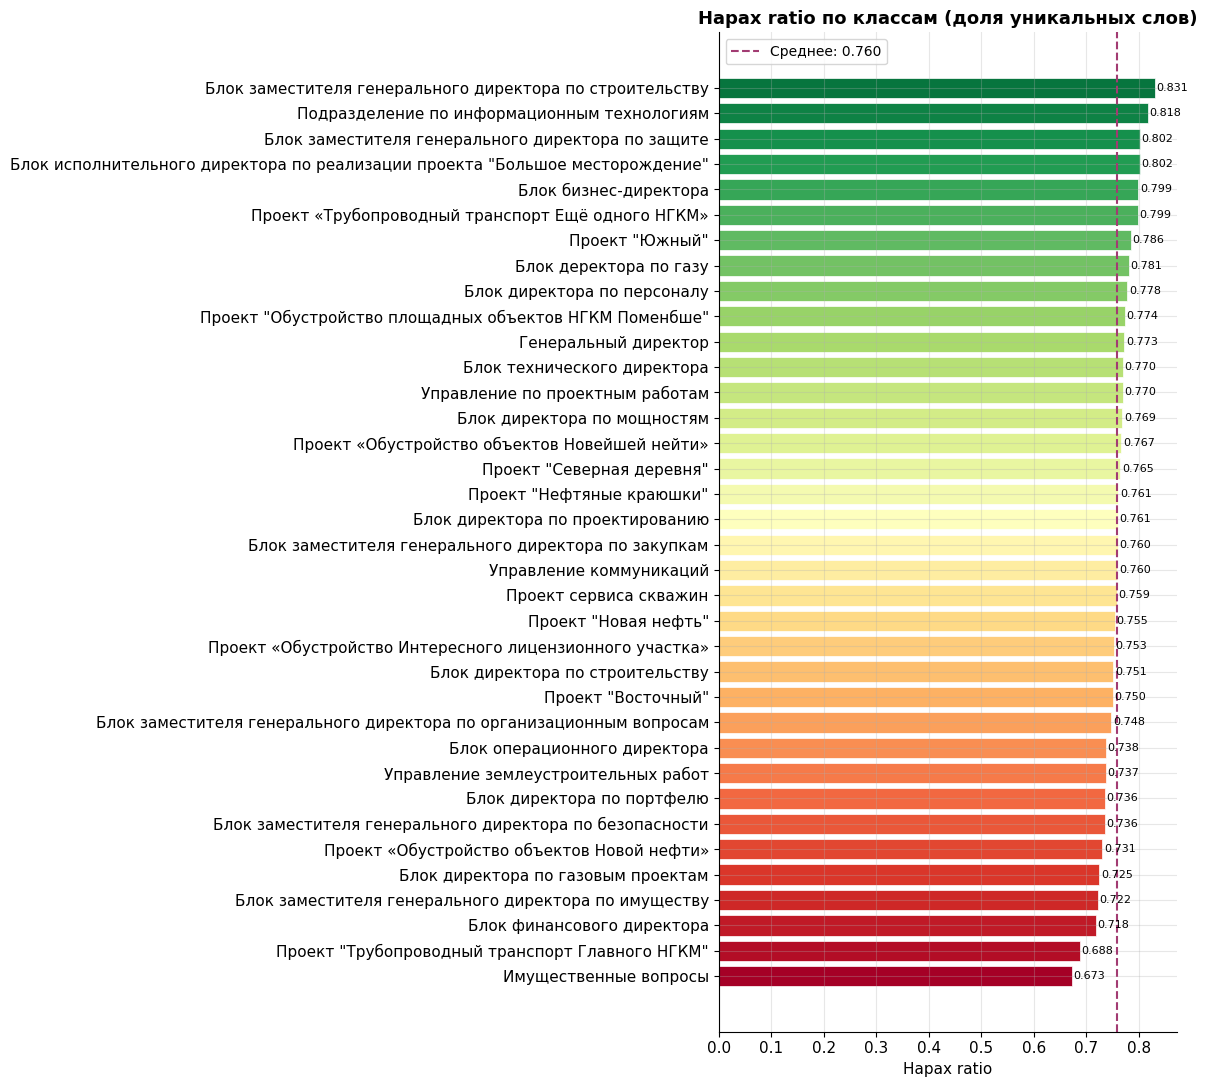

In [14]:
# Hapax ratio по классам
hapax_by_class = df.groupby('label')['hapax_ratio'].mean().sort_values()

n = len(hapax_by_class)
cmap = plt.cm.get_cmap('RdYlGn')
colors = [cmap(i / n) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 11))
bars = ax.barh(hapax_by_class.index, hapax_by_class.values,
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, hapax_by_class.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

ax.axvline(hapax_by_class.mean(), color=PALETTE_ACCENT, linestyle='--',
           linewidth=1.5, label=f'Среднее: {hapax_by_class.mean():.3f}')
ax.set_title('Hapax ratio по классам (доля уникальных слов)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hapax ratio')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/eda_hapax_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Анализ структурных паттернов

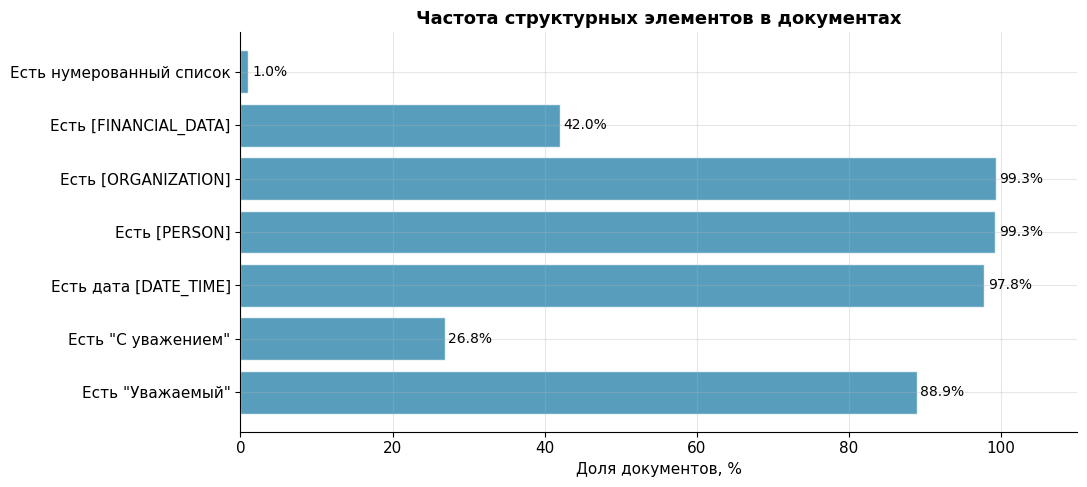

In [15]:
patterns = {
    'Есть "Уважаемый"':      df['text'].str.contains('Уважаем', case=False, na=False),
    'Есть "С уважением"':    df['text'].str.contains('С уважением', case=False, na=False),
    'Есть дата [DATE_TIME]': df['text'].str.contains(r'\[DATE_TIME\]', na=False),
    'Есть [PERSON]':         df['text'].str.contains(r'\[PERSON\]', na=False),
    'Есть [ORGANIZATION]':   df['text'].str.contains(r'\[ORGANIZATION\]', na=False),
    'Есть [FINANCIAL_DATA]': df['text'].str.contains(r'\[FINANCIAL_DATA\]', na=False),
    'Есть нумерованный список': df['text'].str.contains(r'\n\d+\.', na=False),
}

pattern_counts = {k: v.sum() for k, v in patterns.items()}
pattern_pct = {k: v / len(df) * 100 for k, v in pattern_counts.items()}

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(list(pattern_pct.keys()), list(pattern_pct.values()),
               color=PALETTE_MAIN, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, pattern_pct.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Доля документов, %')
ax.set_xlim(0, 110)
ax.set_title('Частота структурных элементов в документах',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. UMAP-визуализация эмбеддингов

Каждый документ кодируется моделью SBERT в вектор размерности 384. UMAP снижает размерность до 2D для визуализации. Цвет точки соответствует классу документа.

In [16]:
from sentence_transformers import SentenceTransformer
import umap

print('Загружаем модель SBERT...')
sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device='cpu')

print('Кодируем документы...')
embeddings = sbert.encode(df['text'].tolist(), batch_size=64,
                          show_progress_bar=True, normalize_embeddings=True)
print(f'Эмбеддинги: {embeddings.shape}')

Загружаем модель SBERT...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Кодируем документы...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Эмбеддинги: (1774, 384)


In [17]:
print('UMAP — снижение размерности...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=40,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
)
embedding_2d = reducer.fit_transform(embeddings)
print('Готово.')

UMAP — снижение размерности...
Готово.


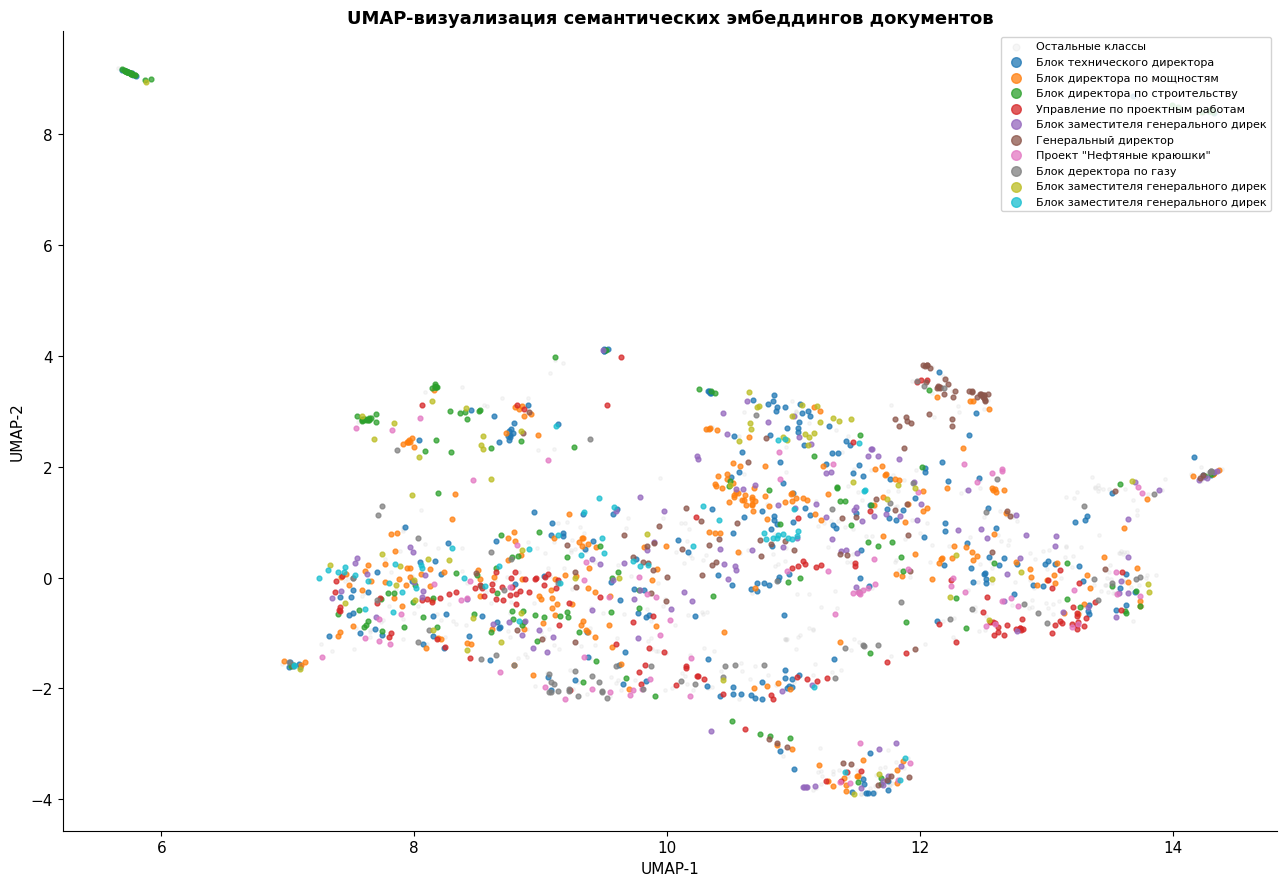

In [18]:
# Показываем топ-10 классов цветами, остальные серые
top10 = label_counts.head(10).index.tolist()
cmap_10 = plt.cm.get_cmap('tab10')
label_color_map = {lbl: cmap_10(i) for i, lbl in enumerate(top10)}

colors_plot = [label_color_map.get(lbl, (0.7, 0.7, 0.7, 0.3))
               for lbl in df['label']]

fig, ax = plt.subplots(figsize=(13, 9))

# Сначала рисуем серые (фон)
mask_other = df['label'].isin(top10)
ax.scatter(embedding_2d[~mask_other, 0], embedding_2d[~mask_other, 1],
           s=6, alpha=0.2, color='lightgray', label='Остальные классы')

# Потом топ-10
for i, lbl in enumerate(top10):
    idx = df['label'] == lbl
    ax.scatter(embedding_2d[idx, 0], embedding_2d[idx, 1],
               s=12, alpha=0.75, color=cmap_10(i),
               label=lbl[:35])

ax.set_title('UMAP-визуализация семантических эмбеддингов документов',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(loc='upper right', fontsize=8, markerscale=2, framealpha=0.85)
ax.grid(False)

plt.tight_layout()
plt.savefig('/content/eda_umap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Итоговые выводы

In [20]:
print('ИТОГИ РАЗВЕДОЧНОГО АНАЛИЗА ДАННЫХ')
print(f'1. Датасет: {len(df)} документов, {df["label"].nunique()} классов')
print(f'2. Дисбаланс: коэффициент {imbalance_ratio:.1f}x')
print(f'   Классов с < 10 документами: {small_10}')
print(f'   Классов с < 20 документами: {small_20}')
print(f'3. Длина текстов: медиана {df["text_len_words"].median():.0f} слов,'
      f' медиана {df["text_len_chars"].median():.0f} символов')
print(f'4. Плейсхолдеры: {len(mask_counts)} уникальных типов,')
print(f'   {docs_with_mask} документов содержат хотя бы один')
print(f'5. TTR: среднее {df["ttr"].mean():.3f} — умеренное лексическое разнообразие')
print()
print('Выводы:')
print('- Выраженный дисбаланс классов требует аугментации данных')
print('- Плейсхолдеры сохраняются при очистке и аугментации')
print('- Большинство документов семантически близки — задача нетривиальна')
print('- Следующий шаг: очистка данных и подготовка к обучению')

ИТОГИ РАЗВЕДОЧНОГО АНАЛИЗА ДАННЫХ
1. Датасет: 1774 документов, 36 классов
2. Дисбаланс: коэффициент 124.5x
   Классов с < 10 документами: 10
   Классов с < 20 документами: 15
3. Длина текстов: медиана 149 слов, медиана 1278 символов
4. Плейсхолдеры: 325 уникальных типов,
   1774 документов содержат хотя бы один
5. TTR: среднее 0.636 — умеренное лексическое разнообразие

Выводы:
- Выраженный дисбаланс классов требует аугментации данных
- Плейсхолдеры сохраняются при очистке и аугментации
- Большинство документов семантически близки — задача нетривиальна
- Следующий шаг: очистка данных и подготовка к обучению
